In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("C:/Medical Appointment No-Show Prediction & Demand Forecasting/Medical_appointment_data.csv")

# Basic info
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

# First 5 rows
df.head()

Shape: (109593, 26)

Columns:
 Index(['specialty', 'appointment_time', 'gender', 'no_show', 'disability',
       'place', 'appointment_shift', 'age', 'under_12_years_old',
       'over_60_years_old', 'patient_needs_companion', 'average_temp_day',
       'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before',
       'storm_day_before', 'rain_intensity', 'heat_intensity',
       'appointment_date_continuous', 'Hipertension', 'Diabetes', 'Alcoholism',
       'Handcap', 'Scholarship', 'SMS_received'],
      dtype='object')


,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
0,psychotherapy,17,F,yes,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
1,NaN,7,M,no,intellectual,ITAPEMA,morning,11.0,1,0,...,1,no_rain,cold,2020-01-01,0,0,0,0,0,0
2,speech therapy,16,M,no,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
3,speech therapy,14,M,yes,intellectual,Sarahside,afternoon,9.0,1,0,...,1,moderate,mild,2020-01-01,0,0,0,0,0,1
4,physiotherapy,8,M,no,motor,ITAJAÍ,morning,NaN,0,0,...,1,no_rain,mild,2020-01-01,0,0,0,0,0,0


In [2]:
# Info
df.info()

# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
print("\nMissing Values:\n", missing)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109593 entries, 0 to 109592
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   specialty                    89466 non-null   object 
 1   appointment_time             109593 non-null  int64  
 2   gender                       109593 non-null  object 
 3   no_show                      109593 non-null  object 
 4   disability                   92992 non-null   object 
 5   place                        98054 non-null   object 
 6   appointment_shift            109593 non-null  object 
 7   age                          86633 non-null   float64
 8   under_12_years_old           109593 non-null  int64  
 9   over_60_years_old            109593 non-null  int64  
 10  patient_needs_companion      109593 non-null  int64  
 11  average_temp_day             107382 non-null  float64
 12  average_rain_day             107348 non-null  float64
 13 

In [3]:
# Target distribution
print(df['no_show'].value_counts())
print(df['no_show'].value_counts(normalize=True))

no_show
no     74761
yes    34832
Name: count, dtype: int64
no_show
no     0.682169
yes    0.317831
Name: proportion, dtype: float64


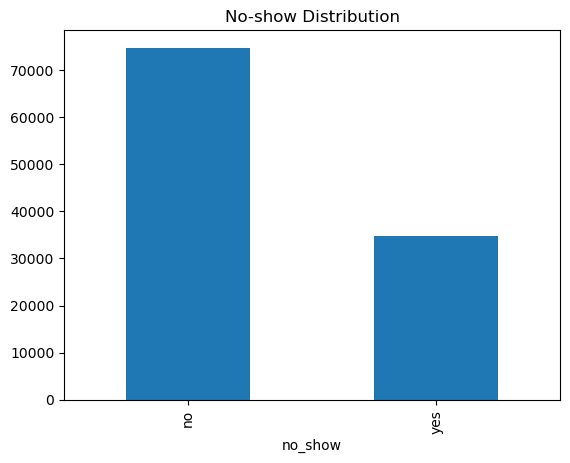

In [4]:
import matplotlib.pyplot as plt

df['no_show'].value_counts().plot(kind='bar')
plt.title("No-show Distribution")
plt.show()

In [5]:
df['no_show'] = df['no_show'].map({'Yes': 1, 'No': 0})

In [9]:
# Age
if 'age' in df.columns:
    df['age'] = df['age'].fillna(df['age'].median())

# Specialty
if 'specialty' in df.columns:
    df['specialty'] = df['specialty'].fillna('Unknown')

# Disability / Handicap
if 'disability' in df.columns:
    df['disability'] = df['disability'].fillna('Unknown')
elif 'handcap' in df.columns:
    df['handcap'] = df['handcap'].fillna(df['handcap'].mode()[0])

# Place / Neighbourhood
if 'place' in df.columns:
    df['place'] = df['place'].fillna(df['place'].mode()[0])
elif 'neighbourhood' in df.columns:
    df['neighbourhood'] = df['neighbourhood'].fillna(df['neighbourhood'].mode()[0])

In [10]:
df['appointment_date_continuous'] = pd.to_datetime(df['appointment_date_continuous'])

In [11]:
df['day_of_week'] = df['appointment_date_continuous'].dt.dayofweek
df['month'] = df['appointment_date_continuous'].dt.month
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['gender', 'specialty', 'place', 'appointment_shift']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [23]:
# Convert target
df['no_show'] = df['no_show'].map({'Yes': 1, 'No': 0})

# Remove rows where target is missing
df = df.dropna(subset=['no_show'])

In [25]:
X = df.drop(['no_show'], axis=1)
y = df['no_show']

In [26]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target distribution:\n", y.value_counts())

X shape: (0, 28)
y shape: (0,)
Target distribution:
 Series([], Name: count, dtype: int64)


In [29]:
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
except Exception as e:
    print("Error:", e)

Error: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.


In [31]:
# Age
if 'age' in df.columns:
    df['age'] = df['age'].fillna(df['age'].median())

# Specialty
if 'specialty' in df.columns:
    if df['specialty'].isnull().all():
        df['specialty'] = df['specialty'].fillna('Unknown')
    else:
        df['specialty'] = df['specialty'].fillna(df['specialty'].mode()[0])

# Disability / Handicap
if 'disability' in df.columns:
    if df['disability'].isnull().all():
        df['disability'] = df['disability'].fillna('Unknown')
    else:
        df['disability'] = df['disability'].fillna(df['disability'].mode()[0])

elif 'handcap' in df.columns:
    if df['handcap'].isnull().all():
        df['handcap'] = df['handcap'].fillna(0)
    else:
        df['handcap'] = df['handcap'].fillna(df['handcap'].mode()[0])

# Place / Neighbourhood
if 'place' in df.columns:
    if df['place'].isnull().all():
        df['place'] = df['place'].fillna('Unknown')
    else:
        df['place'] = df['place'].fillna(df['place'].mode()[0])

elif 'neighbourhood' in df.columns:
    if df['neighbourhood'].isnull().all():
        df['neighbourhood'] = df['neighbourhood'].fillna('Unknown')
    else:
        df['neighbourhood'] = df['neighbourhood'].fillna(df['neighbourhood'].mode()[0])

In [33]:
print(X.dtypes)

specialty                               int64
appointment_time                        int64
gender                                  int64
disability                             object
place                                   int64
appointment_shift                       int64
age                                   float64
under_12_years_old                      int64
over_60_years_old                       int64
patient_needs_companion                 int64
average_temp_day                      float64
average_rain_day                      float64
max_temp_day                          float64
max_rain_day                          float64
rainy_day_before                        int64
storm_day_before                        int64
rain_intensity                         object
heat_intensity                         object
appointment_date_continuous    datetime64[ns]
Hipertension                            int64
Diabetes                                int64
Alcoholism                        

In [49]:
from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

In [50]:
from sklearn.preprocessing import LabelEncoder

for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype == 'O':
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

In [51]:
for col in df.columns:
    print(col, df[col].apply(type).nunique())

specialty 1
appointment_time 1
gender 1
no_show 1
disability 1
place 1
appointment_shift 1
age 1
under_12_years_old 1
over_60_years_old 1
patient_needs_companion 1
average_temp_day 1
average_rain_day 1
max_temp_day 1
max_rain_day 1
rainy_day_before 1
storm_day_before 1
rain_intensity 1
heat_intensity 1
appointment_date_continuous 1
hipertension 1
diabetes 1
alcoholism 1
handcap 1
scholarship 1
sms_received 1


In [52]:
from sklearn.model_selection import train_test_split

X = df.drop('no_show', axis=1)
y = df['no_show']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("SUCCESS")

SUCCESS


In [53]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train, y_train = sm.fit_resample(X_train, y_train)

print("After SMOTE:\n", y_train.value_counts())

After SMOTE:
 no_show
1    59809
0    59809
Name: count, dtype: int64


In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Logistic Regression
              precision    recall  f1-score   support

           0       0.75      0.73      0.74     14952
           1       0.45      0.48      0.47      6967

    accuracy                           0.65     21919
   macro avg       0.60      0.61      0.60     21919
weighted avg       0.66      0.65      0.65     21919

ROC-AUC: 0.6346465284287933


C:\Users\princ\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [55]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Random Forest
              precision    recall  f1-score   support

           0       0.79      0.80      0.79     14952
           1       0.55      0.53      0.54      6967

    accuracy                           0.72     21919
   macro avg       0.67      0.67      0.67     21919
weighted avg       0.71      0.72      0.71     21919

ROC-AUC: 0.7725441713948729


In [57]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [58]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

print("XGBoost")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

C:\Users\princ\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:07:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost
              precision    recall  f1-score   support

           0       0.78      0.82      0.80     14952
           1       0.56      0.51      0.53      6967

    accuracy                           0.72     21919
   macro avg       0.67      0.66      0.67     21919
weighted avg       0.71      0.72      0.71     21919

ROC-AUC: 0.7726993927575562


In [59]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importance.head(10))

                        feature  importance
4                         place    0.165482
10             average_temp_day    0.097536
13                 max_rain_day    0.094133
18  appointment_date_continuous    0.093215
12                 max_temp_day    0.090913
6                           age    0.083603
11             average_rain_day    0.065645
1              appointment_time    0.061649
0                     specialty    0.047462
3                    disability    0.034676


In [60]:
df['appointment_date_continuous'] = pd.to_datetime(df['appointment_date_continuous'])

In [61]:
daily_df = df.groupby('appointment_date_continuous').size().reset_index(name='appointments')

daily_df.head()

,appointment_date_continuous,appointments
0,1970-01-01 00:00:00.000000000,25
1,1970-01-01 00:00:00.000000001,33
2,1970-01-01 00:00:00.000000002,18
3,1970-01-01 00:00:00.000000003,16
4,1970-01-01 00:00:00.000000004,15


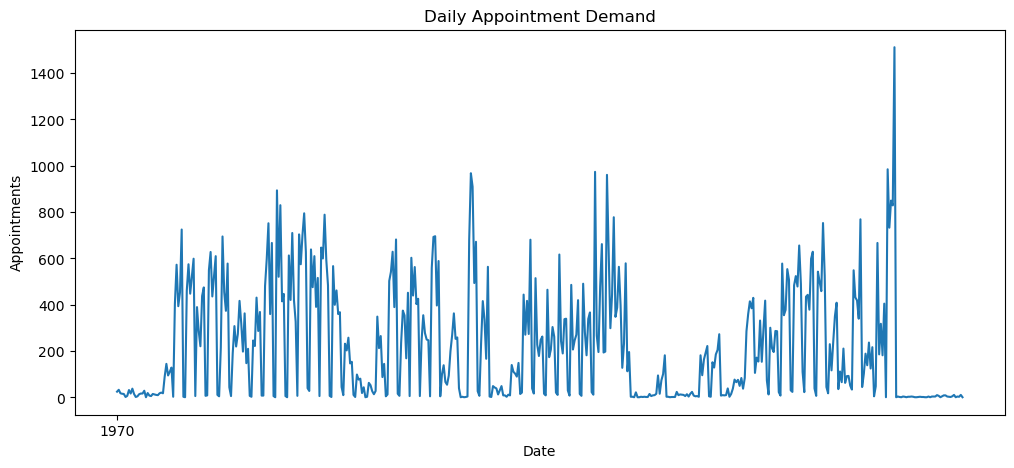

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(daily_df['appointment_date_continuous'], daily_df['appointments'])
plt.title("Daily Appointment Demand")
plt.xlabel("Date")
plt.ylabel("Appointments")
plt.show()

In [63]:
train_size = int(len(daily_df) * 0.8)

train = daily_df[:train_size]
test = daily_df[train_size:]

In [64]:
daily_df['day_number'] = range(len(daily_df))

train = daily_df[:train_size]
test = daily_df[train_size:]

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(train[['day_number']], train['appointments'])

pred = model.predict(test[['day_number']])

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['appointments'], pred)
rmse = np.sqrt(mean_squared_error(test['appointments'], pred))
mape = np.mean(np.abs((test['appointments'] - pred) / test['appointments'])) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 210.65029220076255
RMSE: 284.8898332278922
MAPE: 3142.774455725718


In [66]:
daily_df['day_of_week'] = daily_df['appointment_date_continuous'].dt.dayofweek
daily_df['month'] = daily_df['appointment_date_continuous'].dt.month

In [67]:
train = daily_df[:train_size]
test = daily_df[train_size:]

X_train = train[['day_number', 'day_of_week', 'month']]
y_train = train['appointments']

X_test = test[['day_number', 'day_of_week', 'month']]
y_test = test['appointments']

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

pred = rf_model.predict(X_test)

In [68]:
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mape = np.mean(np.abs((y_test - pred) / y_test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 203.62129999999993
RMSE: 300.7388937683319
MAPE: 2223.8440058881147


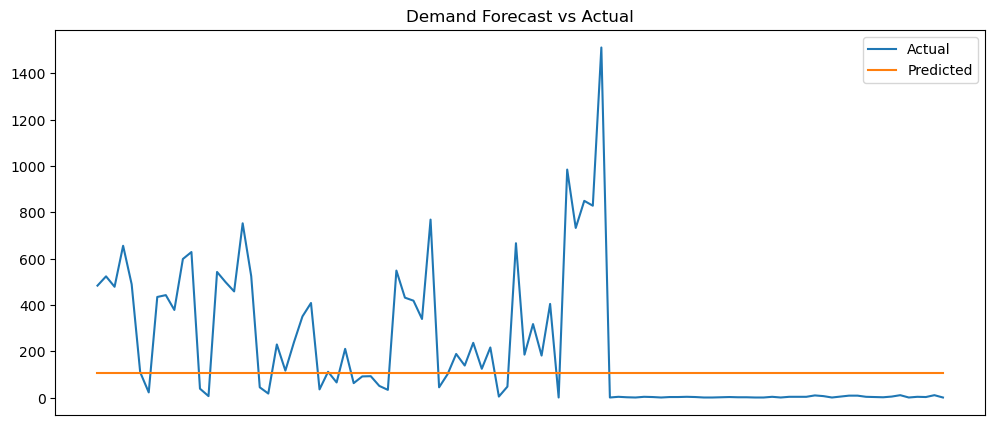

In [69]:
plt.figure(figsize=(12,5))
plt.plot(test['appointment_date_continuous'], y_test, label='Actual')
plt.plot(test['appointment_date_continuous'], pred, label='Predicted')
plt.legend()
plt.title("Demand Forecast vs Actual")
plt.show()

In [70]:
import joblib

# Save classification model (use your best one, e.g., RandomForest or XGBoost)
joblib.dump(rf, "no_show_model.pkl")

# Save demand model
joblib.dump(rf_model, "demand_model.pkl")

# Save feature columns
joblib.dump(X.columns.tolist(), "features.pkl")

['features.pkl']

In [4]:
# ---------------- LOAD DATA ---------------- #
import pandas as pd

df = pd.read_csv("C:/Medical Appointment No-Show Prediction & Demand Forecasting/Medical_appointment_data.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# ---------------- TARGET FIX ---------------- #
df['no_show'] = df['no_show'].astype(str).str.strip().str.lower()
df['no_show'] = df['no_show'].map({'yes': 1, 'no': 0})

df = df.dropna(subset=['no_show']).reset_index(drop=True)

# ---------------- MISSING VALUES ---------------- #
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna('Unknown')

# ---------------- ENCODING ---------------- #
from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# ---------------- SPLIT ---------------- #
from sklearn.model_selection import train_test_split

X = df.drop('no_show', axis=1)
y = df['no_show']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------- SMOTE ---------------- #
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

# ---------------- MODEL ---------------- #
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# ---------------- SAVE MODEL ---------------- #
import joblib

joblib.dump(rf, "no_show_model.pkl")
joblib.dump(X.columns.tolist(), "features.pkl")

print("MODEL SAVED")

              precision    recall  f1-score   support

           0       0.78      0.80      0.79     14952
           1       0.55      0.52      0.54      6967

    accuracy                           0.71     21919
   macro avg       0.67      0.66      0.66     21919
weighted avg       0.71      0.71      0.71     21919

ROC-AUC: 0.7723549193119623
MODEL SAVED


In [6]:
import joblib

joblib.dump(rf, r"C:\Medical Appointment No-Show Prediction & Demand Forecasting\no_show_model.pkl")
joblib.dump(X.columns.tolist(), r"C:\Medical Appointment No-Show Prediction & Demand Forecasting\features.pkl")

print("Saved in correct folder")

Saved in correct folder


In [7]:
import joblib

model = joblib.load(r"C:\Medical Appointment No-Show Prediction & Demand Forecasting\no_show_model.pkl")
features = joblib.load(r"C:\Medical Appointment No-Show Prediction & Demand Forecasting\features.pkl")